<a href="https://colab.research.google.com/github/1617376/proyectojava/blob/main/Trabajo_final_jckl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# proyecto integrador prediccion de compra en campana de marketing de ropa online
# trabajo final individual de machine learning
# contexto es de marketing / e-commerce
# problema es predecir si un cliente va a comprar despues de recibir una campana (correo + descuento)
# dataset marketing_ropa csv (si tienes uno real de kaggle de campanas de e-commerce, reemplazalo aca con las mismas columnas)
!pip install nltk

In [2]:
# importo pandas para manejar tablas de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [3]:
# como no tengo el csv real de kaggle a la mano armo un dataset simulado
# que respeta la misma logica de una campana real (esto se puede reemplazar
# por pd.read_csv('tu_archivo.csv') si tienes el csv real con las mismas columnas)
rng = np.random.default_rng(7)
n = 500

edad = rng.integers(18, 65, n)
genero = rng.choice(['Femenino', 'Masculino'], n, p=[0.62, 0.38])
ingreso_anual = np.round(rng.normal(45000, 15000, n)).clip(12000, 120000)
minutos_en_web = np.round(rng.exponential(6, n) + 1, 1).clip(0.5, 40)
paginas_vistas = rng.poisson(5, n).clip(1, 30)
compras_previas = rng.poisson(2, n).clip(0, 15)
uso_descuento = rng.choice([1, 0], n, p=[0.45, 0.55])
abrio_email = rng.choice([1, 0], n, p=[0.55, 0.45])
canal = rng.choice(['Instagram', 'Email', 'Google Ads', 'TikTok'], n, p=[0.35, 0.30, 0.20, 0.15])

# la compra depende sobre todo de si uso el descuento y si abrio el email
score = (2.3*uso_descuento + 1.4*abrio_email + 0.15*compras_previas
         + 0.08*paginas_vistas + 0.05*minutos_en_web + rng.normal(0, 1.4, n))
umbral = np.quantile(score, 0.55)
compro = np.where(score > umbral, 'Si', 'No')

data = pd.DataFrame({
    'Edad': edad, 'Genero': genero, 'Ingreso_Anual': ingreso_anual.astype(int),
    'Minutos_en_Web': minutos_en_web, 'Paginas_Vistas': paginas_vistas,
    'Compras_Previas': compras_previas, 'Uso_Descuento': uso_descuento,
    'Abrio_Email': abrio_email, 'Canal': canal, 'Compro': compro,
})
data.head(5)

,Edad,Genero,Ingreso_Anual,Minutos_en_Web,Paginas_Vistas,Compras_Previas,Uso_Descuento,Abrio_Email,Canal,Compro
0,62,Femenino,22345,13.0,2,3,0,0,TikTok,No
1,47,Femenino,49460,31.2,5,2,1,1,Instagram,Si
2,50,Femenino,43358,1.1,5,3,0,1,Google Ads,No
3,60,Femenino,40296,6.3,5,1,1,0,Google Ads,No
4,45,Femenino,43904,3.3,6,4,1,1,Email,Si


In [4]:
# como no tengo el csv real de kaggle a la mano armo un dataset simulado
# que respeta la misma logica de una campana real (esto se puede reemplazar
# por pd.read_csv('tu_archivo.csv') si tienes el csv real con las mismas columnas)
rng = np.random.default_rng(7)
n = 500

edad = rng.integers(18, 65, n)
genero = rng.choice(['Femenino', 'Masculino'], n, p=[0.62, 0.38])
ingreso_anual = np.round(rng.normal(45000, 15000, n)).clip(12000, 120000)
minutos_en_web = np.round(rng.exponential(6, n) + 1, 1).clip(0.5, 40)
paginas_vistas = rng.poisson(5, n).clip(1, 30)
compras_previas = rng.poisson(2, n).clip(0, 15)
uso_descuento = rng.choice([1, 0], n, p=[0.45, 0.55])
abrio_email = rng.choice([1, 0], n, p=[0.55, 0.45])
canal = rng.choice(['Instagram', 'Email', 'Google Ads', 'TikTok'], n, p=[0.35, 0.30, 0.20, 0.15])

# la compra depende sobre todo de si uso el descuento y si abrio el email
score = (2.3*uso_descuento + 1.4*abrio_email + 0.15*compras_previas
         + 0.08*paginas_vistas + 0.05*minutos_en_web + rng.normal(0, 1.4, n))
umbral = np.quantile(score, 0.55)
compro = np.where(score > umbral, 'Si', 'No')

data = pd.DataFrame({
    'Edad': edad, 'Genero': genero, 'Ingreso_Anual': ingreso_anual.astype(int),
    'Minutos_en_Web': minutos_en_web, 'Paginas_Vistas': paginas_vistas,
    'Compras_Previas': compras_previas, 'Uso_Descuento': uso_descuento,
    'Abrio_Email': abrio_email, 'Canal': canal, 'Compro': compro,
})
data.head(5)

,Edad,Genero,Ingreso_Anual,Minutos_en_Web,Paginas_Vistas,Compras_Previas,Uso_Descuento,Abrio_Email,Canal,Compro
0,62,Femenino,22345,13.0,2,3,0,0,TikTok,No
1,47,Femenino,49460,31.2,5,2,1,1,Instagram,Si
2,50,Femenino,43358,1.1,5,3,0,1,Google Ads,No
3,60,Femenino,40296,6.3,5,1,1,0,Google Ads,No
4,45,Femenino,43904,3.3,6,4,1,1,Email,Si


In [5]:
data.shape

(500, 10)

In [6]:
data.columns

Index(['Edad', 'Genero', 'Ingreso_Anual', 'Minutos_en_Web', 'Paginas_Vistas',
       'Compras_Previas', 'Uso_Descuento', 'Abrio_Email', 'Canal', 'Compro'],
      dtype='object')

In [7]:
data.dtypes

,0
Edad,int64
Genero,object
Ingreso_Anual,int64
Minutos_en_Web,float64
Paginas_Vistas,int64
Compras_Previas,int64
Uso_Descuento,int64
Abrio_Email,int64
Canal,object
Compro,object


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Edad             500 non-null    int64  
 1   Genero           500 non-null    object 
 2   Ingreso_Anual    500 non-null    int64  
 3   Minutos_en_Web   500 non-null    float64
 4   Paginas_Vistas   500 non-null    int64  
 5   Compras_Previas  500 non-null    int64  
 6   Uso_Descuento    500 non-null    int64  
 7   Abrio_Email      500 non-null    int64  
 8   Canal            500 non-null    object 
 9   Compro           500 non-null    object 
dtypes: float64(1), int64(6), object(3)
memory usage: 39.2+ KB


In [9]:
data.describe()

,Edad,Ingreso_Anual,Minutos_en_Web,Paginas_Vistas,Compras_Previas,Uso_Descuento,Abrio_Email
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.782000,44713.664000,7.002000,4.992000,1.986000,0.384000,0.532000
std,13.668216,14569.352435,6.275447,2.238293,1.419095,0.486845,0.499475
min,18.000000,12000.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,34858.250000,2.800000,3.000000,1.000000,0.000000,0.000000
50%,42.000000,44081.000000,4.900000,5.000000,2.000000,0.000000,1.000000
75%,54.000000,54729.750000,8.900000,6.000000,3.000000,1.000000,1.000000
max,64.000000,83575.000000,40.000000,12.000000,8.000000,1.000000,1.000000


In [10]:
# reviso si hay valores nulos en cada columna
data.isnull().sum()

,0
Edad,0
Genero,0
Ingreso_Anual,0
Minutos_en_Web,0
Paginas_Vistas,0
Compras_Previas,0
Uso_Descuento,0
Abrio_Email,0
Canal,0
Compro,0


In [11]:
# reviso filas duplicadas en el dataset
data.duplicated().sum()

np.int64(0)

In [12]:
# creo la variable objetivo en numero
# pongo 1 si el cliente compro y 0 si no compro
data['Compro_num'] = data['Compro'].map({'No': 0, 'Si': 1})
# reviso cuantos casos hay de cada clase
data['Compro_num'].value_counts()

,count
Compro_num,
0,275
1,225


In [13]:
# porcentaje de cada clase
data['Compro_num'].value_counts(normalize=True) * 100

,proportion
Compro_num,
0,55.0
1,45.0


In [14]:
# creo una variable nueva que mide que tanto interactuo el cliente con la web
# junto minutos en el sitio y paginas vistas en un solo indicador
data['Interaccion_Web'] = data['Minutos_en_Web'] * data['Paginas_Vistas']
data[['Minutos_en_Web', 'Paginas_Vistas', 'Interaccion_Web']].head(5)

,Minutos_en_Web,Paginas_Vistas,Interaccion_Web
0,13.0,2,26.0
1,31.2,5,156.0
2,1.1,5,5.5
3,6.3,5,31.5
4,3.3,6,19.8


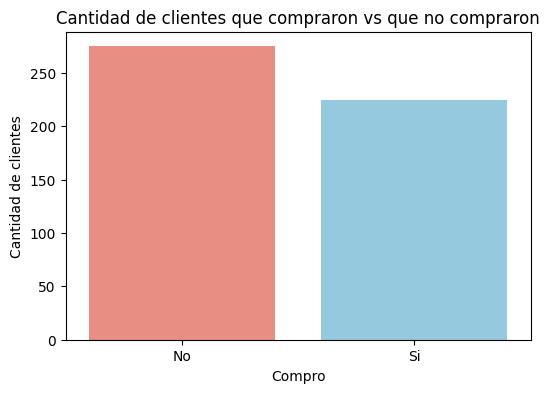

In [15]:
# grafico cuantos clientes compraron contra los que no compraron
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Compro', hue='Compro', palette=['salmon','skyblue'], legend=False)
plt.title('Cantidad de clientes que compraron vs que no compraron')
plt.xlabel('Compro')
plt.ylabel('Cantidad de clientes')
plt.show()

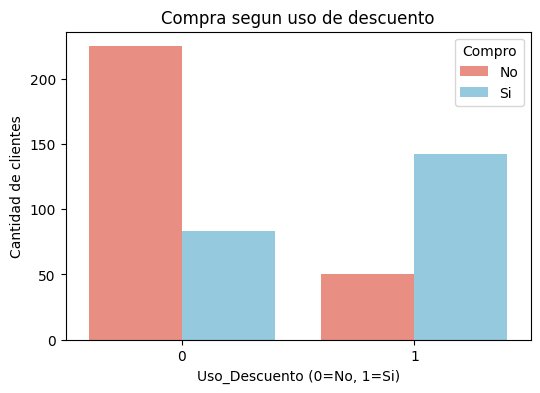

In [16]:
# comparo la compra segun si el cliente uso el descuento de la campana
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Uso_Descuento', hue='Compro', palette=['salmon','skyblue'])
plt.title('Compra segun uso de descuento')
plt.xlabel('Uso_Descuento (0=No, 1=Si)')
plt.ylabel('Cantidad de clientes')
plt.show()

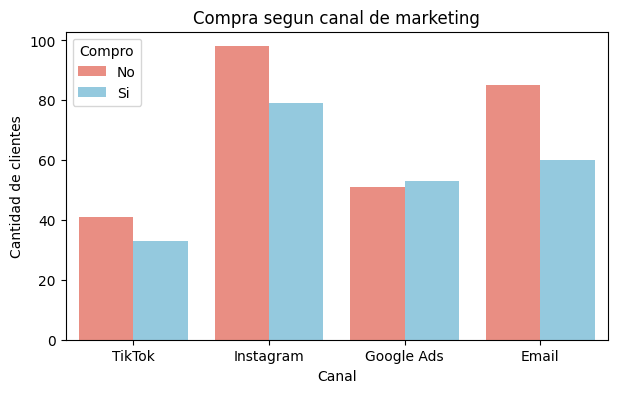

In [17]:
# grafico la compra segun el canal de marketing por donde llego la campana
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='Canal', hue='Compro', palette=['salmon','skyblue'])
plt.title('Compra segun canal de marketing')
plt.xlabel('Canal')
plt.ylabel('Cantidad de clientes')
plt.show()

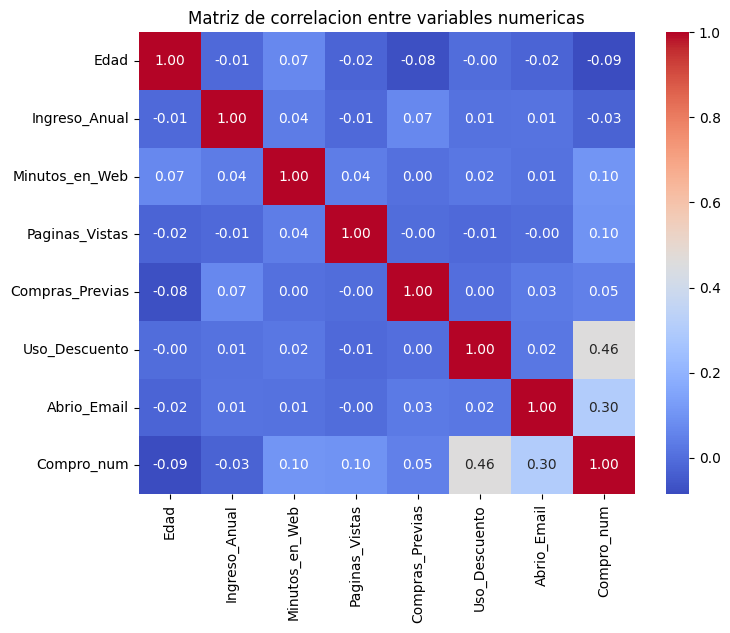

In [19]:
# calculo la correlacion entre las variables numericas
variables_numericas = ['Edad', 'Ingreso_Anual', 'Minutos_en_Web', 'Paginas_Vistas',
                        'Compras_Previas', 'Uso_Descuento', 'Abrio_Email', 'Compro_num']
corr = data[variables_numericas].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion entre variables numericas')
plt.show()

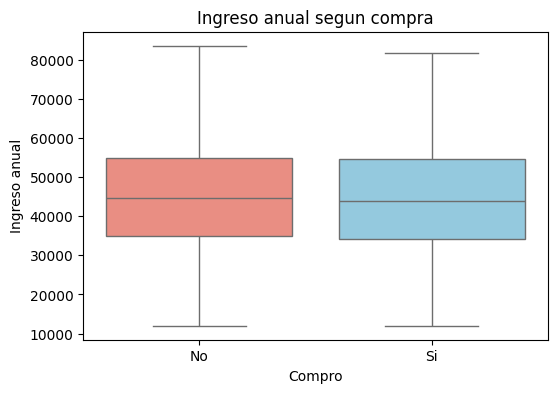

In [20]:
# comparo el ingreso anual segun si el cliente compro o no
plt.figure(figsize=(6,4))
sns.boxplot(x='Compro', y='Ingreso_Anual', data=data, hue='Compro', palette=['salmon','skyblue'])
plt.title('Ingreso anual segun compra')
plt.xlabel('Compro')
plt.ylabel('Ingreso anual')
plt.show()

In [21]:
# armo el set de variables predictoras sacando las columnas de texto/objetivo
X = data.drop(columns=['Compro', 'Compro_num'])
# guardo la variable objetivo aparte
y = data['Compro_num']
# convierto las variables categoricas restantes en variables dummy
X = pd.get_dummies(X, drop_first=True)
# paso todo a tipo float
X = X.astype(float)
X.head(3)

,Edad,Ingreso_Anual,Minutos_en_Web,Paginas_Vistas,Compras_Previas,Uso_Descuento,Abrio_Email,Interaccion_Web,Genero_Masculino,Canal_Google Ads,Canal_Instagram,Canal_TikTok
0,62.0,22345.0,13.0,2.0,3.0,0.0,0.0,26.0,0.0,0.0,0.0,1.0
1,47.0,49460.0,31.2,5.0,2.0,1.0,1.0,156.0,0.0,0.0,1.0,0.0
2,50.0,43358.0,1.1,5.0,3.0,0.0,1.0,5.5,0.0,1.0,0.0,0.0


In [22]:
# cuantas columnas quedaron en total
X.shape

(500, 12)

In [23]:
# separo los datos en entrenamiento y prueba
# uso stratify para mantener la misma proporcion de compra en los dos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('X_train', X_train.shape)
print('X_test', X_test.shape)

X_train (400, 12)
X_test (100, 12)


In [24]:
# creo el escalador
scaler = StandardScaler()
# ajusto y transformo el set de entrenamiento
X_train_esc = scaler.fit_transform(X_train)
# transformo el set de prueba con el mismo escalador
X_test_esc = scaler.transform(X_test)

In [25]:
# creo el modelo de regresion logistica (modelo base)
modelo_rl = LogisticRegression(max_iter=2000)
# entreno el modelo
modelo_rl.fit(X_train_esc, y_train)

LogisticRegression(max_iter=2000)

In [26]:
# uso el modelo para predecir sobre el set de prueba
y_pred_rl = modelo_rl.predict(X_test_esc)
# muestro las primeras 20 predicciones
y_pred_rl[0:20]

array([1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0])

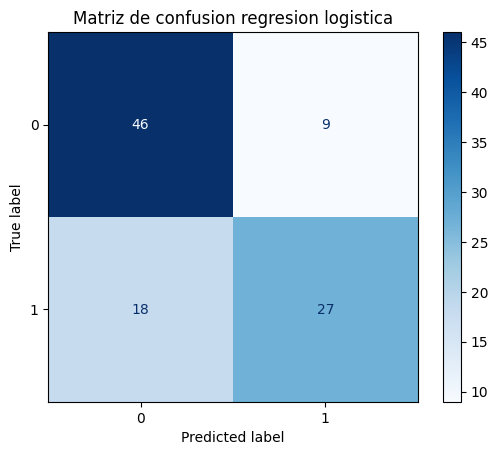

In [27]:
# grafico la matriz de confusion del modelo de regresion logistica
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rl, cmap='Blues')
plt.title('Matriz de confusion regresion logistica')
plt.show()

In [28]:
# imprimo el reporte de metricas del modelo
print(classification_report(y_test, y_pred_rl))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        55
           1       0.75      0.60      0.67        45

    accuracy                           0.73       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.73      0.73       100



In [29]:
# saco las probabilidades de la clase positiva
y_prob_rl = modelo_rl.predict_proba(X_test_esc)[:,1]
# calculo los puntos de la curva roc
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_prob_rl)
# calculo el area bajo la curva
auc_rl = auc(fpr_rl, tpr_rl)
print('AUC regresion logistica', round(auc_rl,3))

AUC regresion logistica 0.784


In [30]:
# saco las probabilidades de la clase positiva
y_prob_rl = modelo_rl.predict_proba(X_test_esc)[:,1]
# calculo los puntos de la curva roc
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_prob_rl)
# calculo el area bajo la curva
auc_rl = auc(fpr_rl, tpr_rl)
print('AUC regresion logistica', round(auc_rl,3))

AUC regresion logistica 0.784


In [31]:
# creo el modelo de arbol de decision (modelo de comparacion)
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
# entreno el modelo
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [32]:
# predigo sobre el set de prueba
y_pred_arbol = modelo_arbol.predict(X_test)
# imprimo el reporte de metricas
print(classification_report(y_test, y_pred_arbol))

              precision    recall  f1-score   support

           0       0.66      0.75      0.70        55
           1       0.63      0.53      0.58        45

    accuracy                           0.65       100
   macro avg       0.65      0.64      0.64       100
weighted avg       0.65      0.65      0.65       100



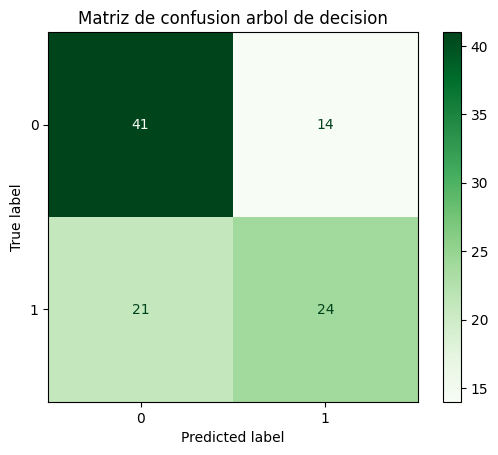

In [33]:
# grafico la matriz de confusion del arbol de decision
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbol, cmap='Greens')
plt.title('Matriz de confusion arbol de decision')
plt.show()

In [34]:
# saco las probabilidades del arbol de decision
y_prob_arbol = modelo_arbol.predict_proba(X_test)[:,1]
# calculo los puntos de la curva roc
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, y_prob_arbol)
# calculo el area bajo la curva
auc_arbol = auc(fpr_arbol, tpr_arbol)
print('AUC arbol de decision', round(auc_arbol,3))

AUC arbol de decision 0.686


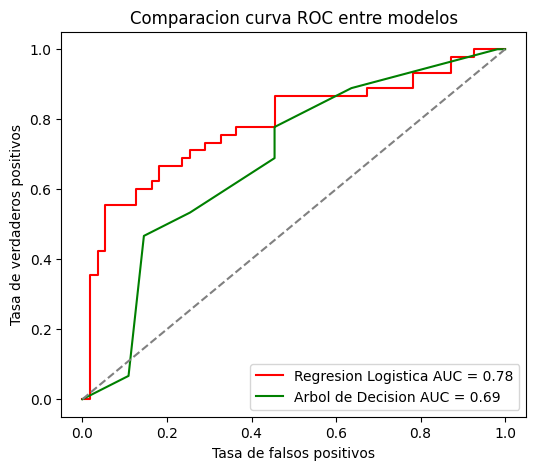

In [35]:
# grafico las dos curvas roc juntas para comparar
plt.figure(figsize=(6,5))
plt.plot(fpr_rl, tpr_rl, label='Regresion Logistica AUC = %0.2f' % auc_rl, color='red')
plt.plot(fpr_arbol, tpr_arbol, label='Arbol de Decision AUC = %0.2f' % auc_arbol, color='green')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title('Comparacion curva ROC entre modelos')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.show()

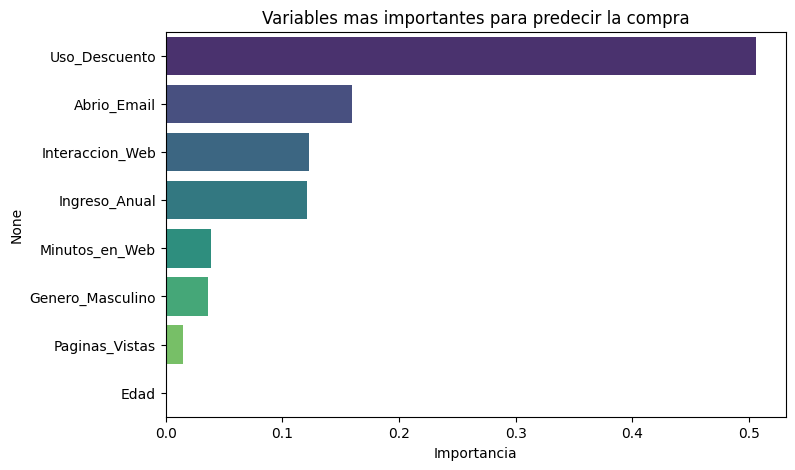

In [36]:
# saco la importancia de cada variable segun el arbol de decision
importancias = pd.Series(modelo_arbol.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(8)
plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False)
plt.title('Variables mas importantes para predecir la compra')
plt.xlabel('Importancia')
plt.show()

In [37]:
# convierto los datos a array de numpy para keras
X_train_dl = np.asarray(X_train_esc).astype('float32')
y_train_dl = np.asarray(y_train).astype('float32')
X_test_dl = np.asarray(X_test_esc).astype('float32')
y_test_dl = np.asarray(y_test).astype('float32')
X_train_dl.shape

(400, 12)

In [38]:
# armo la arquitectura de la red neuronal
modelo_dl = keras.Sequential([
    layers.Input(shape=(X_train_dl.shape[1],)),
    layers.Dense(12, activation='relu'),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
modelo_dl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# compilo el modelo indicando optimizador, perdida y metrica
modelo_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
# entreno la red neuronal
# uso el 20 por ciento del set de entrenamiento como validacion
historial = modelo_dl.fit(
    X_train_dl, y_train_dl,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4219 - loss: 0.7628 - val_accuracy: 0.4375 - val_loss: 0.7450
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4719 - loss: 0.7222 - val_accuracy: 0.4875 - val_loss: 0.7105
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4906 - loss: 0.6922 - val_accuracy: 0.4625 - val_loss: 0.6849
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5531 - loss: 0.6707 - val_accuracy: 0.5500 - val_loss: 0.6617
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6125 - loss: 0.6496 - val_accuracy: 0.6625 - val_loss: 0.6478
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6562 - loss: 0.6317 - val_accuracy: 0.6750 - val_loss: 0.6331
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6969 - loss: 0.6157 - val_accuracy: 0.7000 - val_loss: 0.6162
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6969 - loss: 0.5991 - val_accuracy: 0.7125 - val_lo

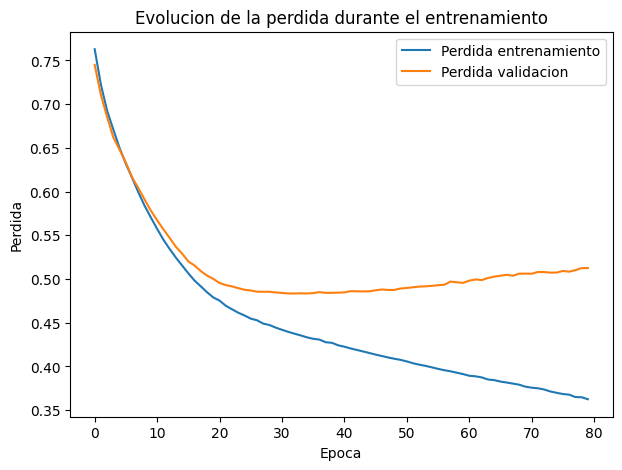

In [41]:
# grafico como baja la perdida en entrenamiento y validacion
plt.figure(figsize=(7,5))
plt.plot(historial.history['loss'], label='Perdida entrenamiento')
plt.plot(historial.history['val_loss'], label='Perdida validacion')
plt.title('Evolucion de la perdida durante el entrenamiento')
plt.xlabel('Epoca')
plt.ylabel('Perdida')
plt.legend()
plt.show()

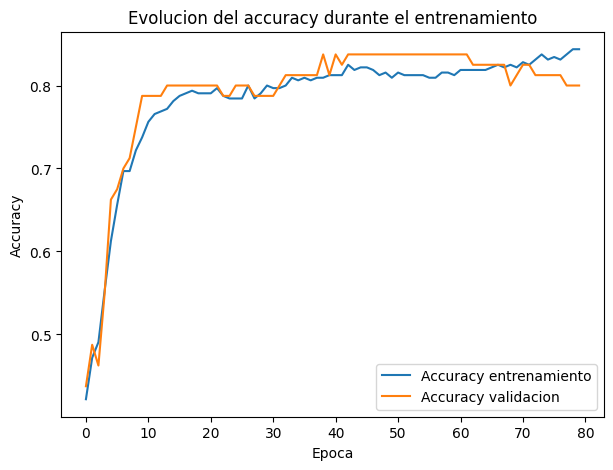

In [42]:
# grafico como sube el accuracy en entrenamiento y validacion
plt.figure(figsize=(7,5))
plt.plot(historial.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Accuracy validacion')
plt.title('Evolucion del accuracy durante el entrenamiento')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [43]:
# evaluo el modelo final sobre el set de prueba
perdida_test, accuracy_test = modelo_dl.evaluate(X_test_dl, y_test_dl, verbose=0)
print('Perdida en test', round(perdida_test,4))
print('Accuracy en test', round(accuracy_test,4))

Perdida en test 0.6871
Accuracy en test 0.67


In [44]:
# saco las probabilidades que da la red neuronal
y_prob_dl = modelo_dl.predict(X_test_dl).ravel()
# paso las probabilidades a clase usando un umbral de 0.5
y_pred_dl = (y_prob_dl >= 0.5).astype(int)
print(classification_report(y_test_dl, y_pred_dl))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

         0.0       0.69      0.73      0.71        55
         1.0       0.64      0.60      0.62        45

    accuracy                           0.67       100
   macro avg       0.67      0.66      0.66       100
weighted avg       0.67      0.67      0.67       100



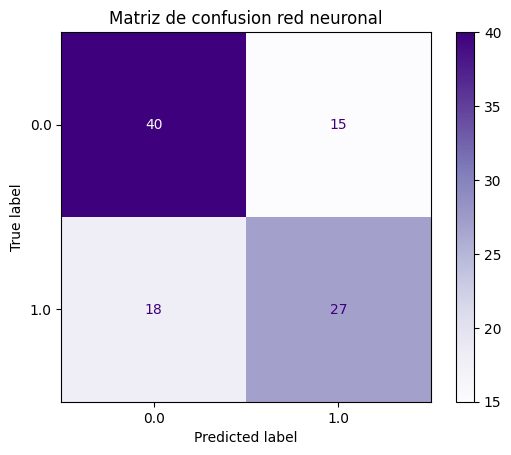

In [45]:
# grafico la matriz de confusion de la red neuronal
ConfusionMatrixDisplay.from_predictions(y_test_dl, y_pred_dl, cmap='Purples')
plt.title('Matriz de confusion red neuronal')
plt.show()

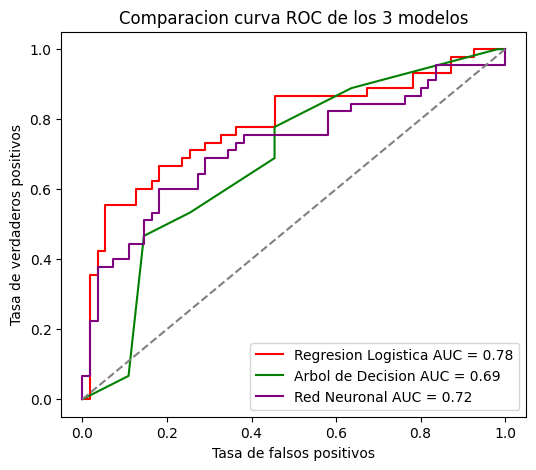

In [46]:
# calculo la curva roc de la red neuronal
fpr_dl, tpr_dl, _ = roc_curve(y_test_dl, y_prob_dl)
auc_dl = auc(fpr_dl, tpr_dl)
# grafico las tres curvas juntas para comparar los tres modelos
plt.figure(figsize=(6,5))
plt.plot(fpr_rl, tpr_rl, label='Regresion Logistica AUC = %0.2f' % auc_rl, color='red')
plt.plot(fpr_arbol, tpr_arbol, label='Arbol de Decision AUC = %0.2f' % auc_arbol, color='green')
plt.plot(fpr_dl, tpr_dl, label='Red Neuronal AUC = %0.2f' % auc_dl, color='purple')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title('Comparacion curva ROC de los 3 modelos')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.show()

In [47]:
# descargo el diccionario de sentimiento que usa nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [48]:
# el dataset original no trae texto libre asi que armo unos comentarios de ejemplo
# esto simula lo que los clientes podrian escribir sobre la campana o la compra
comentarios = pd.DataFrame({
    'comentario': [
        'El descuento de la campana estuvo buenisimo, compre altiro',
        'Nunca me llego el codigo del descuento y perdi la oferta',
        'Me encanto la ropa que vi en el correo, la calidad es excelente',
        'La pagina web es lenta y se tranca al pagar, mala experiencia',
        'El envio llego rapido y la ropa es igual a la foto, muy conforme',
        'No entendi bien la promocion, la publicidad es confusa',
        'Excelente atencion por instagram, me ayudaron a elegir mi talla',
        'El precio subio despues de aplicar el cupon, sensacion de estafa',
    ]
})
comentarios

,comentario
0,"El descuento de la campana estuvo buenisimo, c..."
1,Nunca me llego el codigo del descuento y perdi...
2,"Me encanto la ropa que vi en el correo, la cal..."
3,"La pagina web es lenta y se tranca al pagar, m..."
4,El envio llego rapido y la ropa es igual a la ...
5,"No entendi bien la promocion, la publicidad es..."
6,"Excelente atencion por instagram, me ayudaron ..."
7,"El precio subio despues de aplicar el cupon, s..."


In [49]:
# creo el analizador de sentimiento de nltk
sia = SentimentIntensityAnalyzer()
# defino una funcion que saca el puntaje compuesto de un texto
def calcular_sentimiento(texto):
    return sia.polarity_scores(texto)['compound']
# aplico la funcion a cada comentario
comentarios['puntaje_sentimiento'] = comentarios['comentario'].apply(calcular_sentimiento)
comentarios

,comentario,puntaje_sentimiento
0,"El descuento de la campana estuvo buenisimo, c...",0.000
1,Nunca me llego el codigo del descuento y perdi...,0.000
2,"Me encanto la ropa que vi en el correo, la cal...",0.000
3,"La pagina web es lenta y se tranca al pagar, m...",0.000
4,El envio llego rapido y la ropa es igual a la ...,0.000
5,"No entendi bien la promocion, la publicidad es...",-0.296
6,"Excelente atencion por instagram, me ayudaron ...",0.000
7,"El precio subio despues de aplicar el cupon, s...",0.000


In [50]:
# defino una funcion que clasifica el puntaje en positivo negativo o neutro
def clasificar_sentimiento(puntaje):
    if puntaje > 0.05:
        return 'positivo'
    elif puntaje < -0.05:
        return 'negativo'
    else:
        return 'neutro'
comentarios['sentimiento'] = comentarios['puntaje_sentimiento'].apply(clasificar_sentimiento)
comentarios

,comentario,puntaje_sentimiento,sentimiento
0,"El descuento de la campana estuvo buenisimo, c...",0.000,neutro
1,Nunca me llego el codigo del descuento y perdi...,0.000,neutro
2,"Me encanto la ropa que vi en el correo, la cal...",0.000,neutro
3,"La pagina web es lenta y se tranca al pagar, m...",0.000,neutro
4,El envio llego rapido y la ropa es igual a la ...,0.000,neutro
5,"No entendi bien la promocion, la publicidad es...",-0.296,negativo
6,"Excelente atencion por instagram, me ayudaron ...",0.000,neutro
7,"El precio subio despues de aplicar el cupon, s...",0.000,neutro


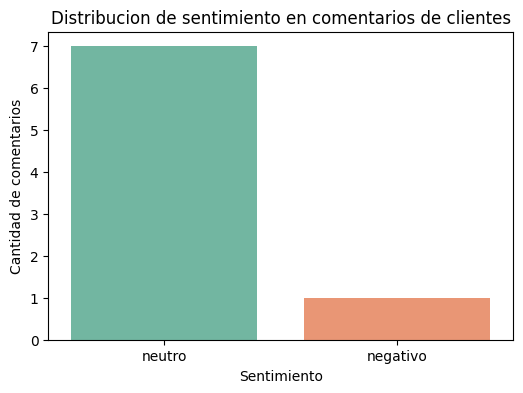

In [51]:
# finalmente grafico cuantos comentarios cayeron en cada categoria de sentimiento
plt.figure(figsize=(6,4))
sns.countplot(data=comentarios, x='sentimiento', hue='sentimiento', palette='Set2', legend=False)
plt.title('Distribucion de sentimiento en comentarios de clientes')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de comentarios')
plt.show()